## 5 - Modeling

Datasets:
- **Base**: `datasets/model_ready_base.csv`
- **Spatial**: `datasets/model_ready_spatial.csv`

Models:
1. OLS linear regression
2. Random Forest regressor
3. XGBoost regressor


## 2. Imports and reproducibility settings


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:
# XGBoost import (macOS fix: ensure OpenMP runtime is discoverable)
import os

_libomp_candidates = [
    "/usr/local/opt/libomp/lib",
    "/opt/homebrew/opt/libomp/lib",
]

for p in _libomp_candidates:
    if os.path.isdir(p):
        os.environ["DYLD_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")
        os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_FALLBACK_LIBRARY_PATH", "")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)
    print("\nIf this is a libomp error on macOS, run:")
    print("- `brew install libomp`")
    print("Then restart the kernel (Kernel → Restart) and rerun.")


XGBoost available: True


In [3]:
# Package versions (reproducibility)
try:
    from importlib.metadata import version
except Exception:
    from importlib_metadata import version  # type: ignore

pkgs = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "xgboost"]
versions = {}
for p in pkgs:
    try:
        versions[p] = version(p)
    except Exception:
        versions[p] = None

print("Package versions:")
for pkg, ver in versions.items():
    print(f"{pkg}: {ver}")



Package versions:
numpy: 2.4.4
pandas: 2.3.3
matplotlib: 3.10.8
seaborn: 0.13.2
scikit-learn: 1.8.0
xgboost: 3.2.0


## 3. Load datasets


In [4]:
# Load full model-ready datasets (produced by notebook 4)
DATA_DIR = Path("datasets")
BASE_PATH = DATA_DIR / "model_ready_base.csv"
SPATIAL_PATH = DATA_DIR / "model_ready_spatial.csv"

base_df_full = pd.read_csv(BASE_PATH, low_memory=False)
spatial_df_full = pd.read_csv(SPATIAL_PATH, low_memory=False)

# Create a held-out test split (municipality-grouped, 80/20 by municipalities)
GROUP_COL = "gm_naam"
RANDOM_STATE = 42
TEST_FRACTION = 0.20

if GROUP_COL not in base_df_full.columns or GROUP_COL not in spatial_df_full.columns:
    raise KeyError(f"Expected grouping column '{GROUP_COL}' in both datasets.")

base_munis = set(base_df_full[GROUP_COL].dropna().unique().tolist())
spatial_munis = set(spatial_df_full[GROUP_COL].dropna().unique().tolist())
if base_munis != spatial_munis:
    raise ValueError("Base/spatial municipality sets differ; cannot do a consistent grouped split.")

munis = sorted(base_munis)
rng = np.random.default_rng(RANDOM_STATE)

test_n_munis = max(1, int(round(TEST_FRACTION * len(munis))))
test_munis = set(rng.choice(munis, size=test_n_munis, replace=False).tolist())
train_munis = set(munis) - test_munis

def split_by_muni(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    is_test = df[GROUP_COL].isin(test_munis)
    return df.loc[~is_test].copy(), df.loc[is_test].copy()

base_train_df, base_test_df = split_by_muni(base_df_full)
spatial_train_df, spatial_test_df = split_by_muni(spatial_df_full)

# Audit summary (printed; not saved)
n_total = len(base_df_full)
print("=== Held-out test split audit (municipality-grouped) ===")
print(f"Rows: total={n_total}, train={len(base_train_df)} ({len(base_train_df)/n_total:.1%}), test={len(base_test_df)} ({len(base_test_df)/n_total:.1%})")
print(f"Municipalities: total={len(munis)}, train={len(train_munis)} ({len(train_munis)/len(munis):.1%}), test={len(test_munis)} ({len(test_munis)/len(munis):.1%})")

# From this point onward, MVP modeling uses TRAIN SPLIT ONLY
base_df = base_train_df
spatial_df = spatial_train_df


=== Held-out test split audit (municipality-grouped) ===
Rows: total=14494, train=11735 (81.0%), test=2759 (19.0%)
Municipalities: total=341, train=273 (80.1%), test=68 (19.9%)


## 4. Inspect columns and select target / ID / grouping variables


In [5]:
# Target/grouping variables
TARGET_COL = "log_crime_count"
GROUP_COL = "gm_naam"

if TARGET_COL not in base_df.columns or TARGET_COL not in spatial_df.columns:
    raise KeyError(f"Expected '{TARGET_COL}' in both datasets.")
if GROUP_COL not in base_df.columns:
    raise KeyError(f"Expected grouping column '{GROUP_COL}' in dataset.")


## 5. Define feature matrices


In [6]:
# Feature selection (numeric predictors only; exclude identifiers and leakage columns)

ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]
ID_COLS_SPATIAL = ID_COLS_BASE.copy()

RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "GeregistreerdeMisdrijven_1",
}

LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)

def select_numeric_predictors(
    df: pd.DataFrame, target: str, id_cols: List[str]
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    df = df.copy()

    leak = [c for c in df.columns if LEAKAGE_REGEX.search(c)]
    exclude = set([c for c in id_cols if c in df.columns]) | set(leak) | set(RAW_TARGET_LIKE) | {target}

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    X = df[feature_cols].copy()
    y = df[target].copy()

    assert target not in X.columns
    assert not any(LEAKAGE_REGEX.search(c) for c in X.columns)

    info = {
        "n_features": len(feature_cols),
        "spillover_cols": [c for c in feature_cols if c.startswith("queen_lag_")],
        "excluded_leakage_cols": leak,
    }
    return X, y, info


X_base, y_base, info_base = select_numeric_predictors(base_df, TARGET_COL, ID_COLS_BASE)
X_spatial, y_spatial, info_spatial = select_numeric_predictors(spatial_df, TARGET_COL, ID_COLS_SPATIAL)


## 6. Define leakage-safe pipelines


In [7]:
# Creates a linear regression pipeline with median imputation and standard scaling.
def make_ols_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

# Creates a random forest regression pipeline with median imputation.
def make_rf_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

# Creates an XGBoost regression pipeline with median imputation; checks XGBoost availability.
def make_xgb_pipeline() -> Pipeline:
    if not XGBOOST_AVAILABLE:
        raise ImportError(
            "xgboost is not available. Install it and rerun. "
            f"Import error was: {XGBOOST_IMPORT_ERROR}"
        )
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


## 7. Cross-validation strategy


In [8]:
def make_cv(groups: Optional[pd.Series]) -> Tuple[Any, str]:
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(n_splits=5) on '{groups.name}'"
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), "KFold(n_splits=5, shuffle=True, random_state=42)"

def print_fold_diagnostics(cv, X: pd.DataFrame, y: pd.Series, groups: Optional[pd.Series]):
    for tr, va in cv.split(X, y, groups):
        if groups is None:
            continue
        gtr = set(groups.iloc[tr].astype(str))
        gva = set(groups.iloc[va].astype(str))
        overlap = gtr.intersection(gva)
        if overlap:
            raise ValueError("Group overlap detected between train and validation folds")


groups_base = base_df[GROUP_COL] if GROUP_COL and GROUP_COL in base_df.columns else None
groups_spatial = spatial_df[GROUP_COL] if GROUP_COL and GROUP_COL in spatial_df.columns else None

cv_base, cv_base_desc = make_cv(groups_base)
cv_spatial, cv_spatial_desc = make_cv(groups_spatial)

print_fold_diagnostics(cv_base, X_base, y_base, groups_base)
print_fold_diagnostics(cv_spatial, X_spatial, y_spatial, groups_spatial)


## Helper functions for evaluation


In [9]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_cv_oof(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    groups: Optional[pd.Series],
    model_name: str,
    dataset_name: str,
    id_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    oof_pred = np.full(len(y), np.nan, dtype=float)
    fold_rows = []

    for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        model_fold = Pipeline(steps=model.steps)
        model_fold.fit(X_tr, y_tr)

        pred_tr = model_fold.predict(X_tr)
        pred_va = model_fold.predict(X_va)

        oof_pred[va] = pred_va

        fold_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "fold": fold,
            "n_train": len(tr),
            "n_val": len(va),
            "rmse_train": rmse(y_tr, pred_tr),
            "rmse_val": rmse(y_va, pred_va),
            "mae_train": float(mean_absolute_error(y_tr, pred_tr)),
            "mae_val": float(mean_absolute_error(y_va, pred_va)),
            "r2_train": float(r2_score(y_tr, pred_tr)),
            "r2_val": float(r2_score(y_va, pred_va)),
        })

    fold_df = pd.DataFrame(fold_rows)

    oof_df = id_df.copy()
    oof_df["dataset"] = dataset_name
    oof_df["model"] = model_name
    oof_df["y_true"] = y.values
    oof_df["y_pred_oof"] = oof_pred
    oof_df["residual"] = oof_df["y_true"] - oof_df["y_pred_oof"]
    oof_df["abs_error"] = oof_df["residual"].abs()

    if np.isnan(oof_pred).any():
        raise RuntimeError("OOF predictions contain NaN")

    return fold_df, oof_df


def summarize_folds(fold_df: pd.DataFrame) -> pd.DataFrame:
    return (
        fold_df.groupby(["dataset", "model"])
        .agg(
            rmse_val_mean=("rmse_val", "mean"),
            rmse_val_std=("rmse_val", "std"),
            mae_val_mean=("mae_val", "mean"),
            mae_val_std=("mae_val", "std"),
            r2_val_mean=("r2_val", "mean"),
            r2_val_std=("r2_val", "std"),
        )
        .reset_index()
        .sort_values(["dataset", "rmse_val_mean"])
    )


## 8–10. Fit and evaluate OLS / RF / XGBoost


In [10]:
# Context columns for diagnostics
KEEP_CONTEXT_COLS = [c for c in ["gwb_code_10", "gm_naam", "regio", "a_inw", "crime_count"] if c in base_df.columns]

id_base = base_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=base_df.index)
id_spatial = spatial_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=spatial_df.index)

# Run MVP CV once (train split only)
models = {
    "OLS": make_ols_pipeline(),
    "RF": make_rf_pipeline(),
}
if XGBOOST_AVAILABLE:
    models["XGB"] = make_xgb_pipeline()

fold_tables = []
oof_tables = []

print("Running MVP CV (train split only)...")
for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_base, y_base, cv_base, groups_base, name, "base", id_base)
    fold_tables.append(fdf)
    oof_tables.append(oof)

for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_spatial, y_spatial, cv_spatial, groups_spatial, name, "spatial", id_spatial)
    fold_tables.append(fdf)
    oof_tables.append(oof)

fold_metrics = pd.concat(fold_tables, ignore_index=True)
oof_predictions = pd.concat(oof_tables, ignore_index=True)

summary = summarize_folds(fold_metrics)
print("\nMVP fold-level summary (validation metrics):")
print(summary.to_string(index=False))


Running MVP CV (train split only)...

MVP fold-level summary (validation metrics):
dataset model  rmse_val_mean  rmse_val_std  mae_val_mean  mae_val_std  r2_val_mean  r2_val_std
   base   XGB       0.582898      0.012008      0.426429     0.004681     0.823979    0.009740
   base    RF       0.603115      0.011830      0.439986     0.004462     0.811664    0.007456
   base   OLS       0.724832      0.025613      0.540249     0.010857     0.728033    0.014174
spatial   XGB       0.578014      0.008215      0.425189     0.003216     0.826745    0.012243
spatial    RF       0.596650      0.007910      0.439561     0.005329     0.815493    0.011081
spatial   OLS       0.704073      0.024235      0.526815     0.009861     0.743397    0.012860


## 11–12. Compare models on base vs spatial



MVP model comparison (mean CV metrics):
dataset model  mean_RMSE  std_RMSE  mean_MAE  std_MAE  mean_R2   std_R2
   base   XGB   0.582898  0.012008  0.426429 0.004681 0.823979 0.009740
   base    RF   0.603115  0.011830  0.439986 0.004462 0.811664 0.007456
   base   OLS   0.724832  0.025613  0.540249 0.010857 0.728033 0.014174
spatial   XGB   0.578014  0.008215  0.425189 0.003216 0.826745 0.012243
spatial    RF   0.596650  0.007910  0.439561 0.005329 0.815493 0.011081
spatial   OLS   0.704073  0.024235  0.526815 0.009861 0.743397 0.012860


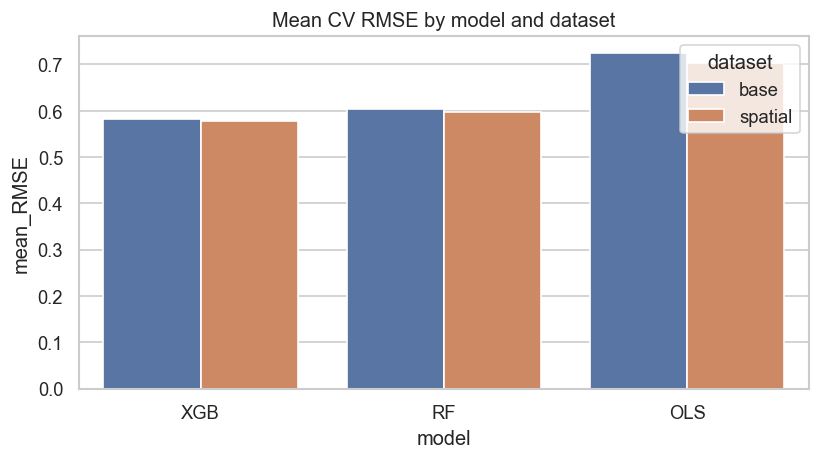

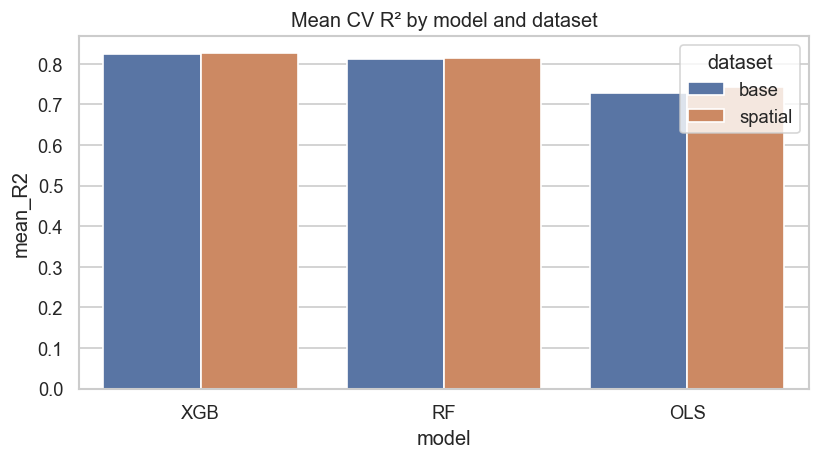

In [11]:
comparison = summary.rename(columns={
    "rmse_val_mean": "mean_RMSE",
    "rmse_val_std": "std_RMSE",
    "mae_val_mean": "mean_MAE",
    "mae_val_std": "std_MAE",
    "r2_val_mean": "mean_R2",
    "r2_val_std": "std_R2",
}).copy()

print("\nMVP model comparison (mean CV metrics):")
print(comparison.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_RMSE", hue="dataset")
plt.title("Mean CV RMSE by model and dataset")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_R2", hue="dataset")
plt.title("Mean CV R² by model and dataset")
plt.tight_layout()
plt.show()



Top OLS coefficients (base, full fit):


,feature,coef
75,a_opp_ha,7.602484
76,a_lan_ha,-7.189829
1,a_inw,-6.474060
66,a_pau,-2.518181
2,a_man,2.463173
57,a_bedv,2.267759
67,a_bst_b,2.207433
15,a_neu_al,1.842799
16,a_geb_nl,1.713022
9,a_ongeh,-1.355399



Top RF permutation importances (val fold): base


,feature,importance
26,a_1p_hh,0.256434
57,a_bedv,0.231306
81,ste_oad,0.047039
60,a_bed_gi,0.041127
33,a_vastg,0.028531
15,a_neu_al,0.022734
74,g_3km_sc,0.017374
75,a_opp_ha,0.005431
76,a_lan_ha,0.004223
20,a_gbl_ne,0.003293


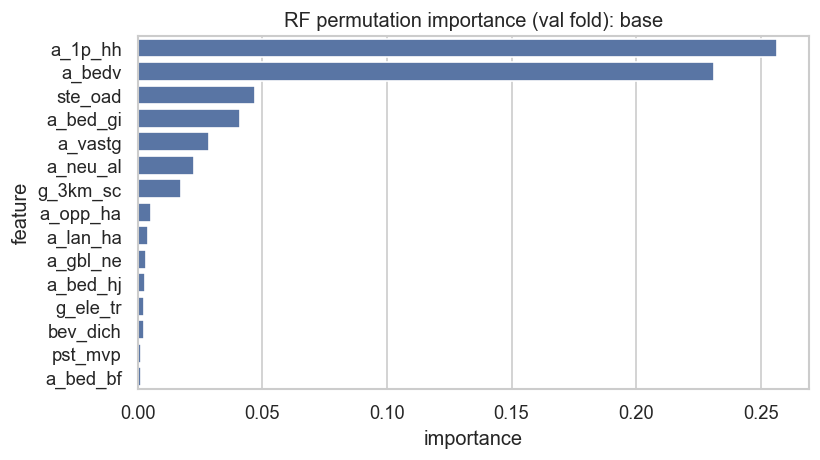


Top RF permutation importances (val fold): spatial


,feature,importance
26,a_1p_hh,0.261242
57,a_bedv,0.167731
60,a_bed_gi,0.039163
33,a_vastg,0.030770
87,queen_lag_sum_a_bedv,0.027191
15,a_neu_al,0.025976
85,queen_lag_sum_a_woning,0.014244
81,ste_oad,0.009400
74,g_3km_sc,0.004697
20,a_gbl_ne,0.002675


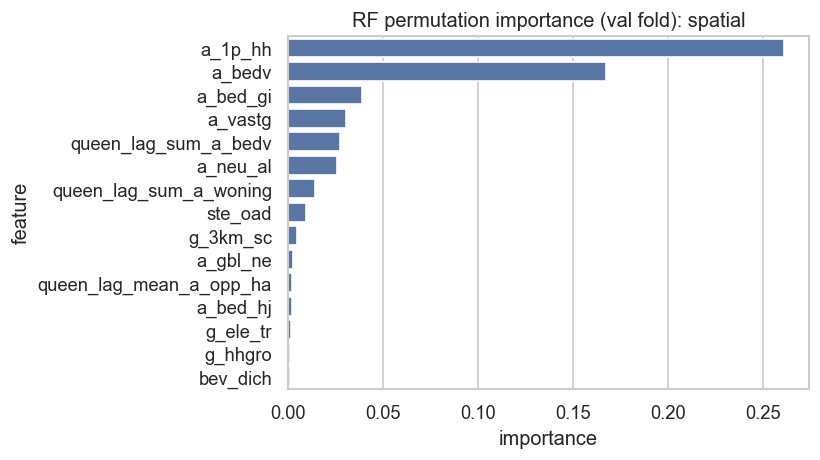


Top XGB feature importances (base, full fit):


,feature,importance
26,a_1p_hh,0.404263
57,a_bedv,0.128540
65,a_bed_ru,0.088799
20,a_gbl_ne,0.050496
15,a_neu_al,0.046355
60,a_bed_gi,0.026006
14,a_eur_al,0.021370
33,a_vastg,0.018953
81,ste_oad,0.011423
74,g_3km_sc,0.007957


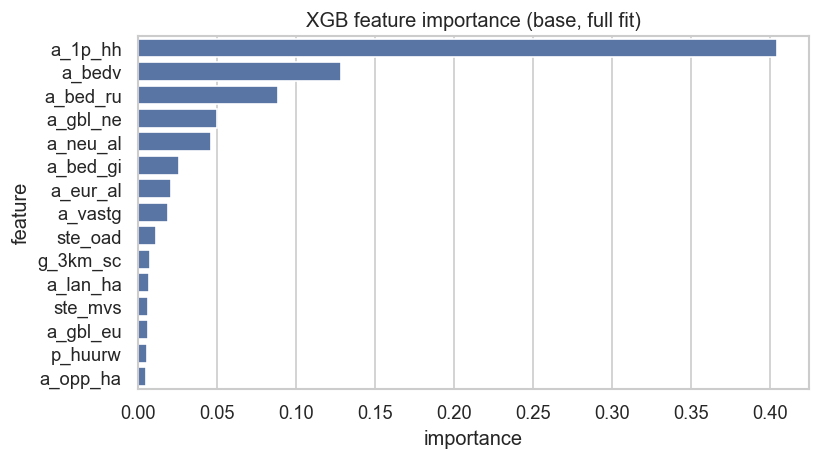


Top XGB feature importances (spatial, full fit):


,feature,importance
26,a_1p_hh,0.337501
57,a_bedv,0.160286
65,a_bed_ru,0.098553
20,a_gbl_ne,0.048879
15,a_neu_al,0.036640
60,a_bed_gi,0.027958
14,a_eur_al,0.019986
33,a_vastg,0.019470
87,queen_lag_sum_a_bedv,0.014972
85,queen_lag_sum_a_woning,0.011861


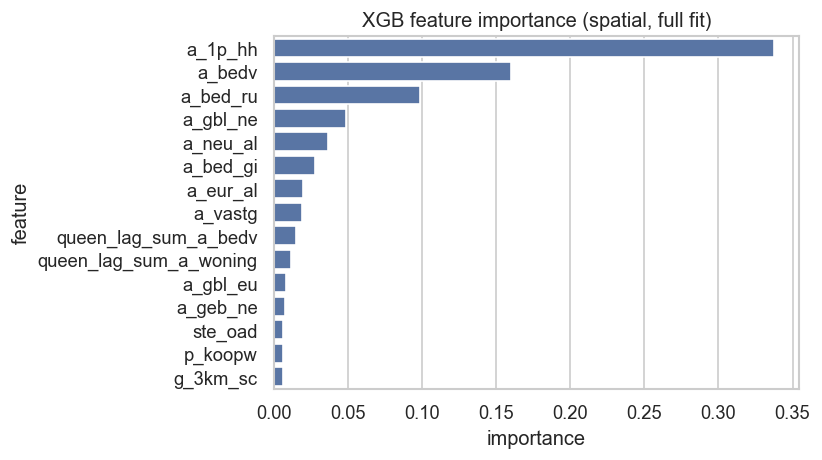

In [12]:
def fit_full(model: Pipeline, X: pd.DataFrame, y: pd.Series) -> Pipeline:
    m = Pipeline(steps=model.steps)
    return m.fit(X, y)

# OLS coefficients (scaled)
ols_full_base = fit_full(make_ols_pipeline(), X_base, y_base)
coef = ols_full_base.named_steps["model"].coef_
ols_coef_df = pd.DataFrame({"feature": X_base.columns, "coef": coef}).sort_values("coef", key=np.abs, ascending=False)
print("\nTop OLS coefficients (base, full fit):")
display(ols_coef_df.head(20))

# RF permutation importance on one validation fold
def rf_perm_imp_one_fold(X, y, cv, groups, tag: str):
    pipe = make_rf_pipeline()
    tr, va = next(iter(cv.split(X, y, groups)))
    pipe.fit(X.iloc[tr], y.iloc[tr])

    try:
        r = permutation_importance(
            pipe,
            X.iloc[va],
            y.iloc[va],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    except Exception as e:
        print("Permutation importance failed; retrying single-process. Error:", repr(e))
        r = permutation_importance(
            pipe,
            X.iloc[va],
            y.iloc[va],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )

    imp = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    print(f"\nTop RF permutation importances (val fold): {tag}")
    display(imp.head(15))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title(f"RF permutation importance (val fold): {tag}")
    plt.tight_layout()
    plt.show()

rf_perm_imp_one_fold(X_base, y_base, cv_base, groups_base, "base")
rf_perm_imp_one_fold(X_spatial, y_spatial, cv_spatial, groups_spatial, "spatial")

if XGBOOST_AVAILABLE:
    xgb_full_base = fit_full(make_xgb_pipeline(), X_base, y_base)
    xgb_model = xgb_full_base.named_steps["model"]
    imp = pd.DataFrame({"feature": X_base.columns, "importance": xgb_model.feature_importances_}).sort_values("importance", ascending=False)
    print("\nTop XGB feature importances (base, full fit):")
    display(imp.head(15))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (base, full fit)")
    plt.tight_layout()
    plt.show()

    xgb_full_spatial = fit_full(make_xgb_pipeline(), X_spatial, y_spatial)
    xgb_model_s = xgb_full_spatial.named_steps["model"]
    imp_s = pd.DataFrame({"feature": X_spatial.columns, "importance": xgb_model_s.feature_importances_}).sort_values("importance", ascending=False)
    print("\nTop XGB feature importances (spatial, full fit):")
    display(imp_s.head(15))

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp_s.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (spatial, full fit)")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not available")


## MVP summary (train split CV only)

This notebook provides a quick MVP comparison on the **training split only**. All thesis figures/SHAP/final performance are produced in notebook 6 on the held-out test set.


In [13]:
best_overall = comparison.sort_values("mean_RMSE").iloc[0]
print("Best MVP configuration by mean CV RMSE (train split only):")
print(best_overall.to_string())


Best MVP configuration by mean CV RMSE (train split only):
dataset       spatial
model             XGB
mean_RMSE    0.578014
std_RMSE     0.008215
mean_MAE     0.425189
std_MAE      0.003216
mean_R2      0.826745
std_R2       0.012243


In [14]:
# Show the compact MVP comparison table
comparison


,dataset,model,mean_RMSE,std_RMSE,mean_MAE,std_MAE,mean_R2,std_R2
2,base,XGB,0.582898,0.012008,0.426429,0.004681,0.823979,0.009740
1,base,RF,0.603115,0.011830,0.439986,0.004462,0.811664,0.007456
0,base,OLS,0.724832,0.025613,0.540249,0.010857,0.728033,0.014174
5,spatial,XGB,0.578014,0.008215,0.425189,0.003216,0.826745,0.012243
4,spatial,RF,0.596650,0.007910,0.439561,0.005329,0.815493,0.011081
3,spatial,OLS,0.704073,0.024235,0.526815,0.009861,0.743397,0.012860


# Improving the models

## Hyperparameter tuning (train split only)

We tune RF and XGBoost using `RandomizedSearchCV` on the **training split only** (municipality-grouped CV). The MVP results above are **not recomputed**.


In [15]:
# Tuning search spaces
rf_param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
    "model__bootstrap": [True],
}

if not XGBOOST_AVAILABLE:
    raise ImportError(f"XGBoost unavailable; cannot run XGB tuning. Error: {XGBOOST_IMPORT_ERROR}")

xgb_param_grid = {
    "model__n_estimators": [300, 500, 800, 1000],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 2, 5],
}

hp_overview = pd.concat(
    [
        pd.DataFrame({"model": "RF", "hyperparameter": list(rf_param_grid.keys()), "values": [str(v) for v in rf_param_grid.values()]}),
        pd.DataFrame({"model": "XGB", "hyperparameter": list(xgb_param_grid.keys()), "values": [str(v) for v in xgb_param_grid.values()]}),
    ],
    ignore_index=True,
)
print("\nHyperparameter search space overview:")
display(hp_overview)

# Helper: tune one model on one dataset

def run_random_search(estimator: Pipeline, param_grid: dict, X, y, cv, groups, n_iter: int, label: str):
    print(f"\n--- Tuning {label} ---")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1,  # keep single-process (BrokenProcessPool safety)
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )
    search.fit(X, y, **({"groups": groups} if groups is not None else {}))

    res = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    print("Best params:")
    print(search.best_params_)
    print(f"Best CV RMSE: {-search.best_score_:.4f}")

    return search.best_estimator_, res

# Tuned RF
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_best_base, rf_res_base = run_random_search(rf_pipe, rf_param_grid, X_base, y_base, cv_base, groups_base, n_iter=30, label="RF (base)")
rf_best_spatial, rf_res_spatial = run_random_search(rf_pipe, rf_param_grid, X_spatial, y_spatial, cv_spatial, groups_spatial, n_iter=30, label="RF (spatial)")

print("\nTop RF tuning results (base):")
display(rf_res_base[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

print("\nTop RF tuning results (spatial):")
display(rf_res_spatial[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

# Tuned XGB
xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
])

xgb_best_base, xgb_res_base = run_random_search(xgb_pipe, xgb_param_grid, X_base, y_base, cv_base, groups_base, n_iter=40, label="XGB (base)")
xgb_best_spatial, xgb_res_spatial = run_random_search(xgb_pipe, xgb_param_grid, X_spatial, y_spatial, cv_spatial, groups_spatial, n_iter=40, label="XGB (spatial)")

print("\nTop XGB tuning results (base):")
display(xgb_res_base[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))

print("\nTop XGB tuning results (spatial):")
display(xgb_res_spatial[["mean_test_score", "std_test_score", "rank_test_score", "params"]].head(10))



Hyperparameter search space overview:


,model,hyperparameter,values
0,RF,model__n_estimators,"[300, 500, 800]"
1,RF,model__max_depth,"[None, 10, 20, 40]"
2,RF,model__min_samples_split,"[2, 5, 10]"
3,RF,model__min_samples_leaf,"[1, 2, 5, 10]"
4,RF,model__max_features,"['sqrt', 'log2', 0.5, 0.8]"
5,RF,model__bootstrap,[True]
6,XGB,model__n_estimators,"[300, 500, 800, 1000]"
7,XGB,model__learning_rate,"[0.01, 0.03, 0.05, 0.1]"
8,XGB,model__max_depth,"[3, 4, 5, 6, 8]"
9,XGB,model__min_child_weight,"[1, 3, 5, 10]"



--- Tuning RF (base) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 40, 'model__bootstrap': True}
Best CV RMSE: 0.5961

--- Tuning RF (spatial) ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best CV RMSE: 0.5914

Top RF tuning results (base):


,mean_test_score,std_test_score,rank_test_score,params
24,-0.596068,0.011746,1,"{'model__n_estimators': 500, 'model__min_sampl..."
8,-0.596069,0.011746,2,"{'model__n_estimators': 500, 'model__min_sampl..."
29,-0.596639,0.011704,3,"{'model__n_estimators': 500, 'model__min_sampl..."
9,-0.597012,0.012755,4,"{'model__n_estimators': 800, 'model__min_sampl..."
18,-0.597031,0.012603,5,"{'model__n_estimators': 800, 'model__min_sampl..."
21,-0.597477,0.012685,6,"{'model__n_estimators': 300, 'model__min_sampl..."
1,-0.598822,0.010832,7,"{'model__n_estimators': 500, 'model__min_sampl..."
22,-0.598877,0.011000,8,"{'model__n_estimators': 300, 'model__min_sampl..."
20,-0.599300,0.011995,9,"{'model__n_estimators': 500, 'model__min_sampl..."
5,-0.599359,0.010516,10,"{'model__n_estimators': 500, 'model__min_sampl..."



Top RF tuning results (spatial):


,mean_test_score,std_test_score,rank_test_score,params
24,-0.591355,0.006886,1,"{'model__n_estimators': 500, 'model__min_sampl..."
8,-0.591355,0.006886,1,"{'model__n_estimators': 500, 'model__min_sampl..."
9,-0.592031,0.008068,3,"{'model__n_estimators': 800, 'model__min_sampl..."
18,-0.592174,0.008210,4,"{'model__n_estimators': 800, 'model__min_sampl..."
29,-0.592503,0.006974,5,"{'model__n_estimators': 500, 'model__min_sampl..."
21,-0.592529,0.007729,6,"{'model__n_estimators': 300, 'model__min_sampl..."
5,-0.593621,0.006954,7,"{'model__n_estimators': 500, 'model__min_sampl..."
1,-0.593825,0.007291,8,"{'model__n_estimators': 500, 'model__min_sampl..."
20,-0.594164,0.007659,9,"{'model__n_estimators': 500, 'model__min_sampl..."
22,-0.594650,0.007622,10,"{'model__n_estimators': 300, 'model__min_sampl..."



--- Tuning XGB (base) ---
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params:
{'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
Best CV RMSE: 0.5771

--- Tuning XGB (spatial) ---
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params:
{'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
Best CV RMSE: 0.5707

Top XGB tuning results (base):


,mean_test_score,std_test_score,rank_test_score,params
21,-0.577106,0.008981,1,"{'model__subsample': 0.6, 'model__reg_lambda':..."
25,-0.577124,0.009771,2,"{'model__subsample': 0.6, 'model__reg_lambda':..."
31,-0.577457,0.009387,3,"{'model__subsample': 0.6, 'model__reg_lambda':..."
14,-0.578344,0.011628,4,"{'model__subsample': 0.6, 'model__reg_lambda':..."
35,-0.578866,0.010821,5,"{'model__subsample': 0.8, 'model__reg_lambda':..."
15,-0.579435,0.010810,6,"{'model__subsample': 0.8, 'model__reg_lambda':..."
5,-0.579869,0.010183,7,"{'model__subsample': 0.8, 'model__reg_lambda':..."
18,-0.579994,0.010601,8,"{'model__subsample': 0.6, 'model__reg_lambda':..."
7,-0.580633,0.008921,9,"{'model__subsample': 0.6, 'model__reg_lambda':..."
26,-0.581307,0.012740,10,"{'model__subsample': 1.0, 'model__reg_lambda':..."



Top XGB tuning results (spatial):


,mean_test_score,std_test_score,rank_test_score,params
21,-0.570666,0.007067,1,"{'model__subsample': 0.6, 'model__reg_lambda':..."
31,-0.571431,0.006076,2,"{'model__subsample': 0.6, 'model__reg_lambda':..."
25,-0.571488,0.005423,3,"{'model__subsample': 0.6, 'model__reg_lambda':..."
15,-0.571705,0.007563,4,"{'model__subsample': 0.8, 'model__reg_lambda':..."
14,-0.572083,0.006406,5,"{'model__subsample': 0.6, 'model__reg_lambda':..."
35,-0.572380,0.005739,6,"{'model__subsample': 0.8, 'model__reg_lambda':..."
18,-0.572933,0.006470,7,"{'model__subsample': 0.6, 'model__reg_lambda':..."
5,-0.572950,0.005571,8,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,-0.573253,0.006969,9,"{'model__subsample': 0.6, 'model__reg_lambda':..."
26,-0.574772,0.007562,10,"{'model__subsample': 1.0, 'model__reg_lambda':..."


## Final evaluation on held-out test set

After tuning, we refit each model on the **full training split** and evaluate once on the **held-out test set**.



Train/Test shapes:
Base train: (11735, 83) Base test: (2759, 83)
Spatial train: (11735, 95) Spatial test: (2759, 95)

=== Hold-out test set performance (RMSE / MAE / R²) ===
model dataset   tuning     rmse      mae       r2
  XGB    base    tuned 0.554639 0.404718 0.839162
  XGB spatial    tuned 0.557878 0.403960 0.837278
   RF    base    tuned 0.572349 0.417777 0.828727
   RF spatial    tuned 0.581385 0.420037 0.823276
  OLS spatial baseline 0.677796 0.513817 0.759804
  OLS    base baseline 0.685178 0.515997 0.754544


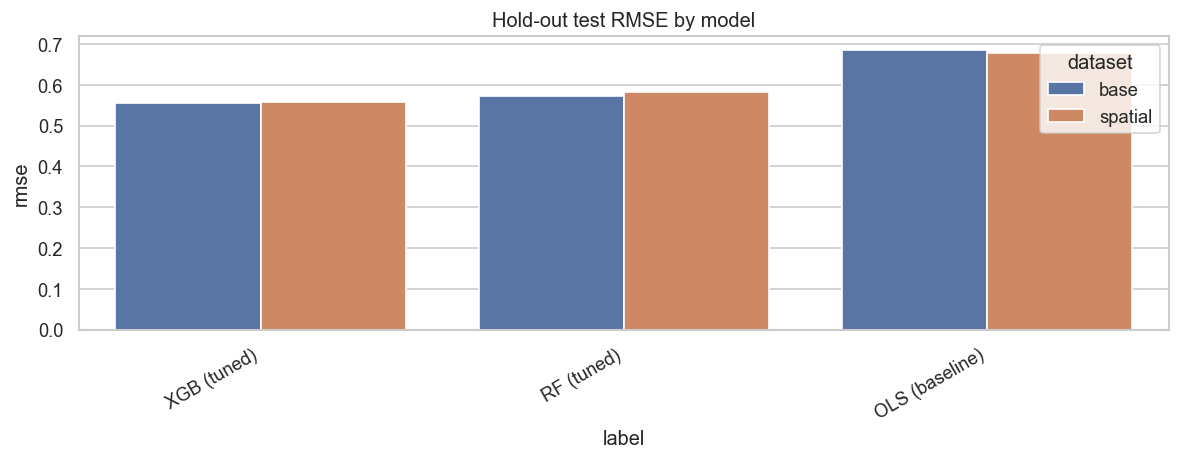

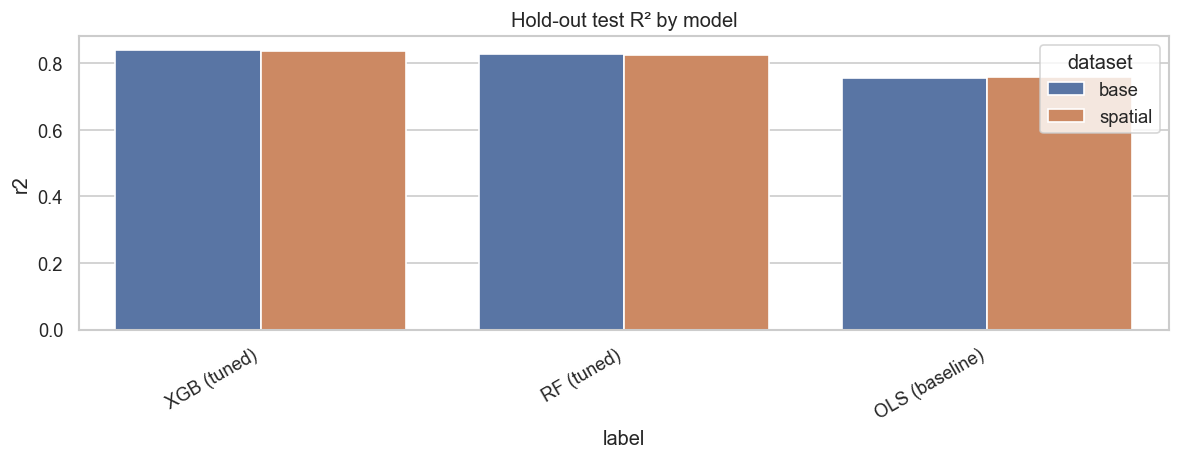

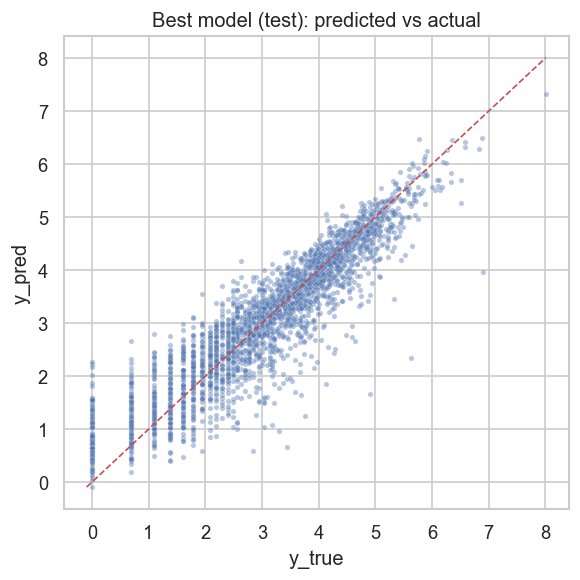

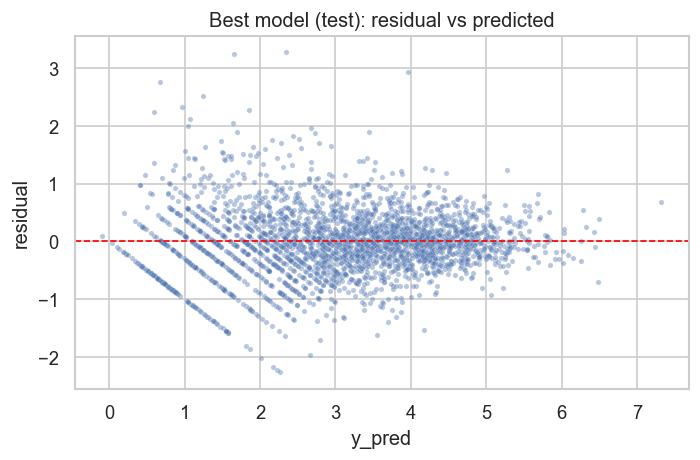

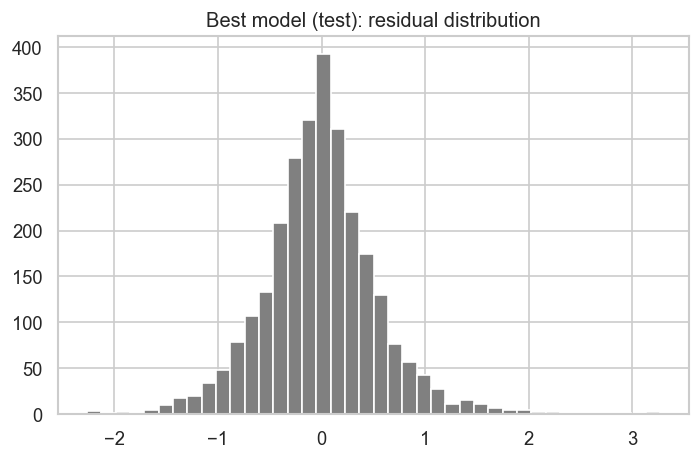

In [16]:
# Build X/y for test split using the same feature-selection logic
X_base_test, y_base_test, _ = select_numeric_predictors(base_test_df, TARGET_COL, ID_COLS_BASE)
X_spatial_test, y_spatial_test, _ = select_numeric_predictors(spatial_test_df, TARGET_COL, ID_COLS_SPATIAL)

# Align columns explicitly (train defines the feature space)
X_base_test = X_base_test.reindex(columns=X_base.columns, fill_value=np.nan)
X_spatial_test = X_spatial_test.reindex(columns=X_spatial.columns, fill_value=np.nan)

print("\nTrain/Test shapes:")
print("Base train:", X_base.shape, "Base test:", X_base_test.shape)
print("Spatial train:", X_spatial.shape, "Spatial test:", X_spatial_test.shape)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def fit_predict_eval(model: Pipeline, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))
    mae = float(mean_absolute_error(yte, pred))
    r2 = float(r2_score(yte, pred))
    return pred, rmse, mae, r2

results = []
preds = []

# Context columns for richer diagnostics
ctx_cols = [c for c in ["gwb_code_10", "gm_naam", "regio", "a_inw", "crime_count"] if c in base_test_df.columns]
ctx_base_test = base_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=base_test_df.index)
ctx_spatial_test = spatial_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=spatial_test_df.index)

# OLS (baseline)
for dataset_type, (Xtr, ytr, Xte, yte, ctx) in {
    "base": (X_base, y_base, X_base_test, y_base_test, ctx_base_test),
    "spatial": (X_spatial, y_spatial, X_spatial_test, y_spatial_test, ctx_spatial_test),
}.items():
    pred, rmse, mae, r2 = fit_predict_eval(make_ols_pipeline(), Xtr, ytr, Xte, yte)
    results.append({"model": "OLS", "dataset": dataset_type, "tuning": "baseline", "rmse": rmse, "mae": mae, "r2": r2})
    dfp = ctx.copy()
    dfp["dataset"] = dataset_type
    dfp["model"] = "OLS"
    dfp["tuning"] = "baseline"
    dfp["y_true"] = yte.values
    dfp["y_pred"] = pred
    dfp["residual"] = dfp["y_true"] - dfp["y_pred"]
    dfp["abs_error"] = dfp["residual"].abs()
    preds.append(dfp)

# RF tuned
pred, rmse, mae, r2 = fit_predict_eval(rf_best_base, X_base, y_base, X_base_test, y_base_test)
results.append({"model": "RF", "dataset": "base", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_base_test.copy(); dfp["dataset"]="base"; dfp["model"]="RF"; dfp["tuning"]="tuned"; dfp["y_true"]=y_base_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(rf_best_spatial, X_spatial, y_spatial, X_spatial_test, y_spatial_test)
results.append({"model": "RF", "dataset": "spatial", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_spatial_test.copy(); dfp["dataset"]="spatial"; dfp["model"]="RF"; dfp["tuning"]="tuned"; dfp["y_true"]=y_spatial_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

# XGB tuned
pred, rmse, mae, r2 = fit_predict_eval(xgb_best_base, X_base, y_base, X_base_test, y_base_test)
results.append({"model": "XGB", "dataset": "base", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_base_test.copy(); dfp["dataset"]="base"; dfp["model"]="XGB"; dfp["tuning"]="tuned"; dfp["y_true"]=y_base_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(xgb_best_spatial, X_spatial, y_spatial, X_spatial_test, y_spatial_test)
results.append({"model": "XGB", "dataset": "spatial", "tuning": "tuned", "rmse": rmse, "mae": mae, "r2": r2})
dfp = ctx_spatial_test.copy(); dfp["dataset"]="spatial"; dfp["model"]="XGB"; dfp["tuning"]="tuned"; dfp["y_true"]=y_spatial_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

final_test = pd.DataFrame(results).sort_values(["rmse", "model", "dataset"]).reset_index(drop=True)
print("\n=== Hold-out test set performance (RMSE / MAE / R²) ===")
print(final_test.to_string(index=False))

test_preds_all = pd.concat(preds, ignore_index=True)

# Quick comparison plots (shown; not saved)
plt.figure(figsize=(10, 4))
plot_df = final_test.copy()
plot_df["label"] = plot_df["model"] + " (" + plot_df["tuning"] + ")"
sns.barplot(data=plot_df, x="label", y="rmse", hue="dataset", errorbar=None)
plt.title("Hold-out test RMSE by model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="label", y="r2", hue="dataset", errorbar=None)
plt.title("Hold-out test R² by model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Best model on test (lowest RMSE)
best_row = final_test.iloc[0]
best_test = test_preds_all[(test_preds_all["model"] == best_row["model"]) & (test_preds_all["dataset"] == best_row["dataset"]) & (test_preds_all["tuning"] == best_row["tuning"])].copy()

plt.figure(figsize=(5, 5))
sns.scatterplot(x=best_test["y_true"], y=best_test["y_pred"], s=10, alpha=0.4)
mn = min(best_test["y_true"].min(), best_test["y_pred"].min())
mx = max(best_test["y_true"].max(), best_test["y_pred"].max())
plt.plot([mn, mx], [mn, mx], "r--", lw=1)
plt.title("Best model (test): predicted vs actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(x=best_test["y_pred"], y=best_test["residual"], s=10, alpha=0.4)
plt.axhline(0, color="red", ls="--", lw=1)
plt.title("Best model (test): residual vs predicted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(best_test["residual"], bins=40, color="gray", edgecolor="white")
plt.title("Best model (test): residual distribution")
plt.tight_layout()
plt.show()


## SHAP (best tuned XGBoost)

If the best test-set model is tuned XGBoost, we compute SHAP values on the held-out test set sample.


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_65325/1445830020.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=feature_names, show=False)


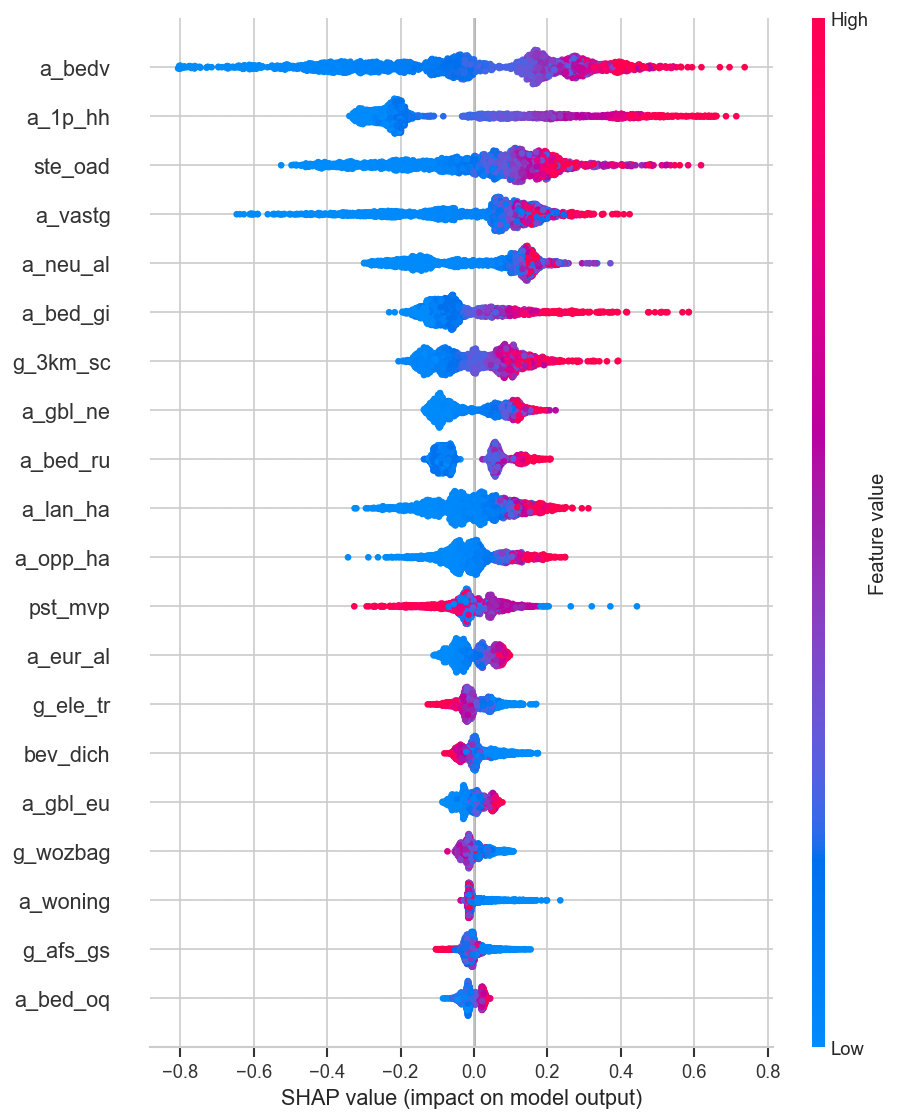


Top SHAP mean(|value|) features:


,feature,mean_abs_shap
0,a_bedv,0.248982
1,a_1p_hh,0.243744
2,ste_oad,0.157111
3,a_vastg,0.146734
4,a_neu_al,0.136078
5,a_bed_gi,0.098144
6,g_3km_sc,0.091762
7,a_gbl_ne,0.087810
8,a_bed_ru,0.083811
9,a_lan_ha,0.082649


In [22]:
if best_row["model"] == "XGB" and best_row["tuning"] == "tuned":
    import shap

    best_pipe = xgb_best_spatial if best_row["dataset"] == "spatial" else xgb_best_base
    Xtr = X_spatial if best_row["dataset"] == "spatial" else X_base
    ytr = y_spatial if best_row["dataset"] == "spatial" else y_base
    Xte = X_spatial_test if best_row["dataset"] == "spatial" else X_base_test

    # Fit once on full train
    best_pipe_full = Pipeline(steps=best_pipe.steps)
    best_pipe_full.fit(Xtr, ytr)

    imputer = best_pipe_full.named_steps.get("imputer")
    model = best_pipe_full.named_steps.get("model")
    if imputer is None or model is None:
        raise ValueError("Expected Pipeline with steps: imputer, model")

    X_imp = imputer.transform(Xte)
    feature_names = list(Xte.columns)

    # Sample for speed
    rng = np.random.RandomState(RANDOM_STATE)
    n = X_imp.shape[0]
    sample_n = min(2000, n)
    idx = rng.choice(n, size=sample_n, replace=False)
    X_s = X_imp[idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_s)

    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_s, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()

    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_df = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    print("\nTop SHAP mean(|value|) features:")
    display(shap_df.head(20))
else:
    print("Best model is not tuned XGB: skipping SHAP.")


## SHAP (forced): tuned XGBoost on spatial dataset

This section computes SHAP values **specifically for the tuned XGBoost spatial model**, independent of which model performed best overall.


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_65325/1361119821.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=feature_names_spatial, show=False)


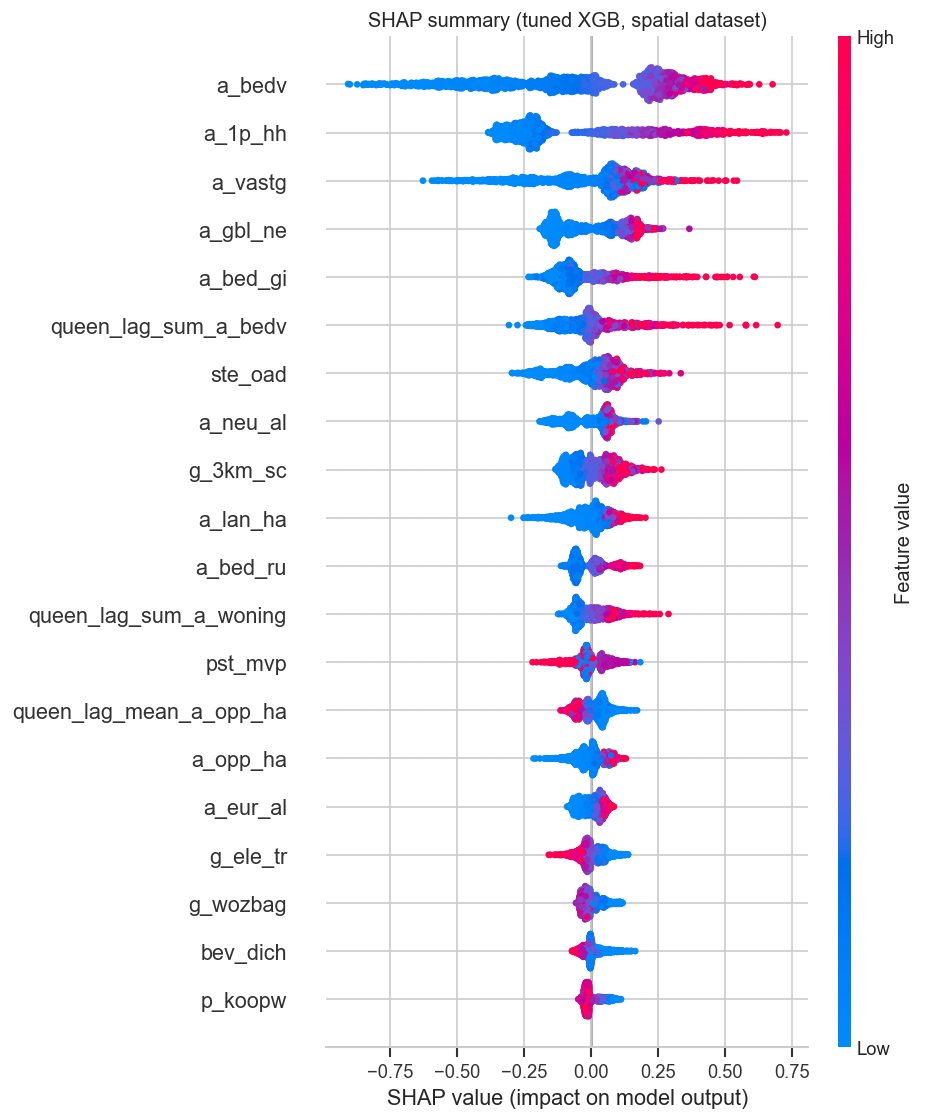


Top SHAP mean(|value|) features (tuned XGB, spatial):


,feature,mean_abs_shap
0,a_bedv,0.284251
1,a_1p_hh,0.256140
2,a_vastg,0.148859
3,a_gbl_ne,0.118369
4,a_bed_gi,0.097404
5,queen_lag_sum_a_bedv,0.083377
6,ste_oad,0.079039
7,a_neu_al,0.069355
8,g_3km_sc,0.067754
9,a_lan_ha,0.054238


In [26]:
# Fit tuned XGB (spatial) on full train and compute SHAP on spatial test

# Guard: make sure tuned spatial XGB exists
if "xgb_best_spatial" not in globals():
    raise NameError("xgb_best_spatial is not defined. Run the tuning section first.")

import shap

# Refit (fresh Pipeline) on full train
xgb_spatial_full = Pipeline(steps=xgb_best_spatial.steps)
xgb_spatial_full.fit(X_spatial, y_spatial)

imputer = xgb_spatial_full.named_steps.get("imputer")
model = xgb_spatial_full.named_steps.get("model")
if imputer is None or model is None:
    raise ValueError("Expected Pipeline with steps: imputer, model")

Xte = X_spatial_test.copy()
feature_names_spatial = list(Xte.columns)

X_imp = imputer.transform(Xte)

# Sample for speed
rng = np.random.RandomState(RANDOM_STATE)
n = X_imp.shape[0]
sample_n = min(2000, n)
idx = rng.choice(n, size=sample_n, replace=False)
X_s = X_imp[idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_s)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_s, feature_names=feature_names_spatial, show=False)
plt.title("SHAP summary (tuned XGB, spatial dataset)")
plt.tight_layout()
plt.show()

mean_abs = np.abs(shap_values).mean(axis=0)
shap_df_spatial_xgb = (
    pd.DataFrame({"feature": feature_names_spatial, "mean_abs_shap": mean_abs})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("\nTop SHAP mean(|value|) features (tuned XGB, spatial):")
display(shap_df_spatial_xgb.head(25))



SHAP comparison: spatial lag features vs base equivalents (tuned XGB, spatial)


,spatial_lag_feature,base_feature,lag_mean_abs_shap,base_mean_abs_shap
0,queen_lag_sum_a_bedv,a_bedv,0.083377,0.284251
1,queen_lag_sum_a_woning,a_woning,0.052033,0.021223
2,queen_lag_mean_a_opp_ha,a_opp_ha,0.040758,0.039210
3,queen_lag_mean_a_ll,a_ll,0.017580,0.005341
4,queen_lag_mean_a_inw,a_inw,0.017326,0.004206
5,queen_lag_sum_a_pau,a_pau,0.015485,0.008511
6,queen_lag_mean_a_pau,a_pau,0.013330,0.008511
7,queen_lag_sum_a_inw,a_inw,0.010623,0.004206
8,queen_lag_mean_a_woning,a_woning,0.007588,0.021223
9,queen_lag_mean_a_bedv,a_bedv,0.006514,0.284251


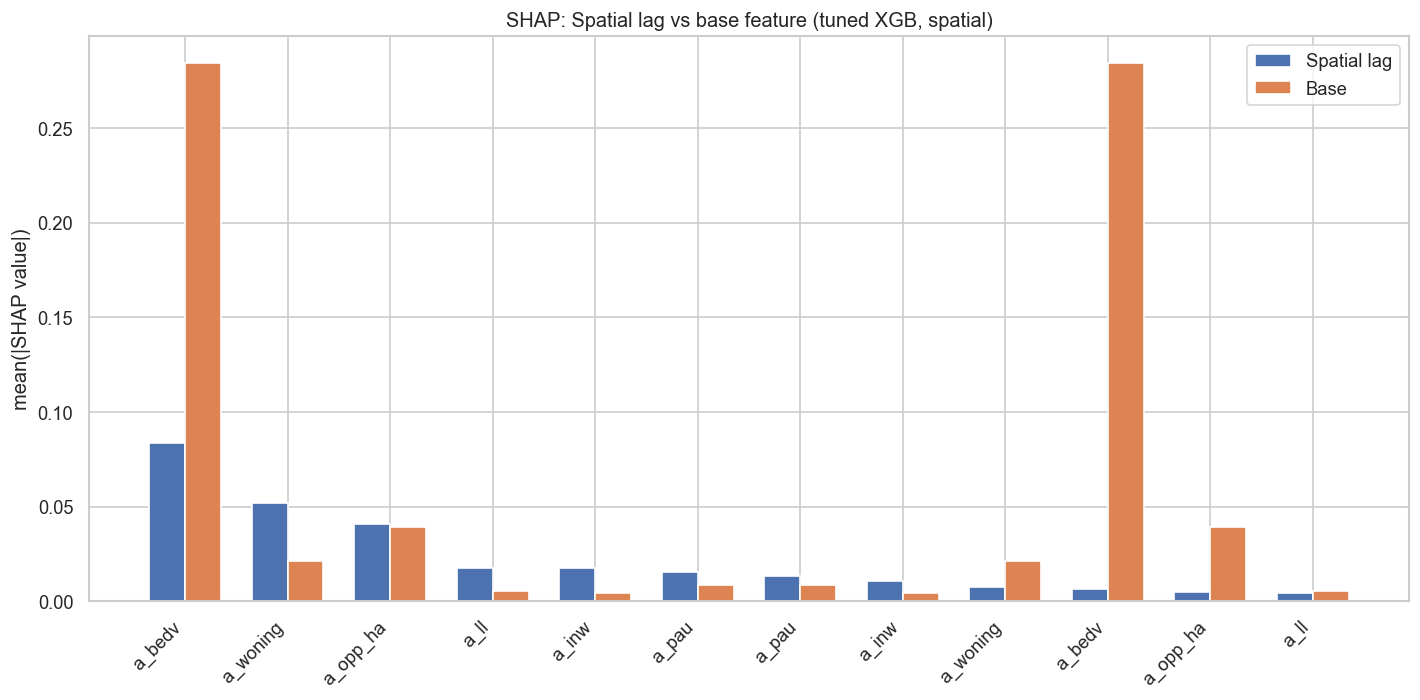

In [27]:
# Compare SHAP: spatial lag features vs their base equivalents (using the spatial XGB SHAP table)

spatial_lag_prefixes = ["queen_lag_sum_", "queen_lag_mean_"]

spatial_lag_features = [
    f for f in shap_df_spatial_xgb["feature"].tolist()
    if any(f.startswith(pref) for pref in spatial_lag_prefixes)
]

def get_base_feature(lag_feature: str):
    for pref in spatial_lag_prefixes:
        if lag_feature.startswith(pref):
            return lag_feature[len(pref):]
    return None

rows = []
for lag_feature in spatial_lag_features:
    base_feature = get_base_feature(lag_feature)

    lag_row = shap_df_spatial_xgb.loc[shap_df_spatial_xgb["feature"] == lag_feature]
    base_row = shap_df_spatial_xgb.loc[shap_df_spatial_xgb["feature"] == base_feature] if base_feature else pd.DataFrame()

    rows.append(
        {
            "spatial_lag_feature": lag_feature,
            "base_feature": base_feature,
            "lag_mean_abs_shap": float(lag_row["mean_abs_shap"].iloc[0]) if not lag_row.empty else np.nan,
            "base_mean_abs_shap": float(base_row["mean_abs_shap"].iloc[0]) if not base_row.empty else np.nan,
        }
    )

lag_vs_base_df = pd.DataFrame(rows, columns=[
    "spatial_lag_feature",
    "base_feature",
    "lag_mean_abs_shap",
    "base_mean_abs_shap",
])

if lag_vs_base_df.empty:
    print("No queen_lag_* features found in SHAP table for spatial XGB.")
else:
    lag_vs_base_df = lag_vs_base_df.dropna(subset=["lag_mean_abs_shap", "base_mean_abs_shap"])
    print("\nSHAP comparison: spatial lag features vs base equivalents (tuned XGB, spatial)")
    display(lag_vs_base_df.sort_values("lag_mean_abs_shap", ascending=False))

    if not lag_vs_base_df.empty:
        plt.figure(figsize=(12, 6))
        ind = np.arange(len(lag_vs_base_df))
        width = 0.35

        plt.bar(ind, lag_vs_base_df["lag_mean_abs_shap"], width, label="Spatial lag")
        plt.bar(ind + width, lag_vs_base_df["base_mean_abs_shap"], width, label="Base")

        plt.xticks(ind + width / 2, lag_vs_base_df["base_feature"], rotation=45, ha="right")
        plt.ylabel("mean(|SHAP value|)")
        plt.title("SHAP: Spatial lag vs base feature (tuned XGB, spatial)")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [25]:
# SHAP lag vs base comparison
# Safe if SHAP was not computed.

spatial_lag_prefixes = ["queen_lag_sum_", "queen_lag_mean_", "row_lag_sum_", "row_lag_mean_"]

required = ["feature_names", "shap_df"]
missing = [r for r in required if r not in globals()]
if missing:
    print(f"Skipping lag-vs-base SHAP comparison (missing: {missing}).")
else:
    spatial_lag_features = [
        f for f in feature_names
        if any(f.startswith(pref) for pref in spatial_lag_prefixes)
    ]

    def get_base_feature(lag_feature: str):
        for pref in spatial_lag_prefixes:
            if lag_feature.startswith(pref):
                return lag_feature[len(pref):]
        return None

    cols = [
        "spatial_lag_feature",
        "base_feature",
        "lag_mean_abs_shap",
        "base_mean_abs_shap",
    ]

    comparison_data = []
    for lag_feature in spatial_lag_features:
        base_feature = get_base_feature(lag_feature)

        lag_row = shap_df.loc[shap_df["feature"] == lag_feature]
        base_row = shap_df.loc[shap_df["feature"] == base_feature] if base_feature is not None else pd.DataFrame()

        lag_shap = lag_row["mean_abs_shap"].iloc[0] if not lag_row.empty else np.nan
        base_shap = base_row["mean_abs_shap"].iloc[0] if not base_row.empty else np.nan

        comparison_data.append(
            {
                "spatial_lag_feature": lag_feature,
                "base_feature": base_feature,
                "lag_mean_abs_shap": lag_shap,
                "base_mean_abs_shap": base_shap,
            }
        )

    lag_vs_base_df = pd.DataFrame(comparison_data, columns=cols)

    if lag_vs_base_df.empty:
        print("No spatial lag features found in this SHAP output.")
    else:
        lag_vs_base_df = lag_vs_base_df.dropna(subset=["lag_mean_abs_shap", "base_mean_abs_shap"])

        print("\nComparison of SHAP values: spatial lag features vs base features")
        display(lag_vs_base_df.sort_values("lag_mean_abs_shap", ascending=False))

        if not lag_vs_base_df.empty:
            plt.figure(figsize=(12, 6))
            ind = np.arange(len(lag_vs_base_df))
            width = 0.35

            plt.bar(ind, lag_vs_base_df["lag_mean_abs_shap"], width, label="Spatial lag")
            plt.bar(ind + width, lag_vs_base_df["base_mean_abs_shap"], width, label="Base")

            plt.xticks(ind + width / 2, lag_vs_base_df["base_feature"], rotation=45, ha="right")
            plt.ylabel("mean(|SHAP value|)")
            plt.title("SHAP Value Comparison: Spatial Lag vs Base Features")
            plt.legend()
            plt.tight_layout()
            plt.show()


No spatial lag features found in this SHAP output.
